[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/10_pandas_sql/10_6_SQL_vs_Pandas.ipynb)

# 10.6: SQL vs pandas: When to Use Each

You now have two tools that answer many of the same questions: SQL and pandas. They are not competitors; each is better suited to certain situations, and in practice, most data workflows use both. This notebook introduces one final SQL concept (subqueries), then steps back to examine how SQL and pandas differ as tools, and how to decide which one to reach for.

In [ ]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_parquet("gapminder.parquet")

countries = df[["country", "continent"]].drop_duplicates().reset_index(drop=True)
measurements = df[["country", "year", "lifeExp", "pop", "gdpPercap"]].copy()

conn = sqlite3.connect(":memory:")
countries.to_sql("countries", conn, index=False, if_exists="replace")
measurements.to_sql("measurements", conn, index=False, if_exists="replace")

print("Ready.")

## Subqueries: a query inside a query

Sometimes the value you want to compare against is not a known constant; it is itself the result of a query. For example: "find all countries whose 2007 life expectancy was above the global average for 2007." The global average needs to be computed first, and then used as a threshold.

In pandas, the natural approach is two steps: compute the mean, store it in a variable, then filter.

In [2]:
# pandas two-step approach
global_avg = df.query("year == 2007")["lifeExp"].mean()
print(f"Global mean life expectancy in 2007: {global_avg:.2f}")

above_avg_pandas = df.query("year == 2007 and lifeExp > @global_avg")[["country", "lifeExp"]]
print(f"{len(above_avg_pandas)} countries above the global mean")

Global mean life expectancy in 2007: 67.01
85 countries above the global mean


This works cleanly in pandas. SQL offers an alternative: a **subquery**, which embeds one `SELECT` inside another. The inner query computes the average; the outer query uses it as a filter. The entire logic lives in one self-contained statement.

In [3]:
above_avg_sql = pd.read_sql("""
    SELECT country, lifeExp
    FROM measurements
    WHERE year = 2007
      AND lifeExp > (
          SELECT AVG(lifeExp)
          FROM measurements
          WHERE year = 2007
      )
    ORDER BY lifeExp DESC
""", conn)

print(f"{len(above_avg_sql)} countries above the global mean")
above_avg_sql.head(10)

85 countries above the global mean


,country,lifeExp
0,Japan,82.603
1,"Hong Kong, China",82.208
2,Iceland,81.757
3,Switzerland,81.701
4,Australia,81.235
5,Spain,80.941
6,Sweden,80.884
7,Israel,80.745
8,France,80.657
9,Canada,80.653


Same result as the pandas version: 71 countries above the global 2007 mean. The subquery, the inner `SELECT` in parentheses, runs first and returns a single value (the global average). The outer query then uses that value in the `WHERE` condition.

Subqueries can also appear in `HAVING` clauses, in `SELECT` lists, and in `FROM` clauses (as a derived table). The pattern you will use most often is in `WHERE`, where you want to compare against a computed threshold rather than a hard-coded number.

## Subqueries with `IN`

A subquery can also return a list of values for use with `IN`. This lets you filter one table based on conditions computed from another, without explicitly writing a JOIN.

In [4]:
# All measurements for countries that had life expectancy below 40 in 1952
short_lived_1952 = pd.read_sql("""
    SELECT country, year, lifeExp
    FROM measurements
    WHERE country IN (
        SELECT country
        FROM measurements
        WHERE year = 1952
          AND lifeExp < 40
    )
    ORDER BY country, year
""", conn)

print(f"Countries with lifeExp < 40 in 1952: {short_lived_1952['country'].nunique()}")
short_lived_1952.pivot(index="year", columns="country", values="lifeExp").round(1)

Countries with lifeExp < 40 in 1952: 40


country,Afghanistan,Angola,Bangladesh,Benin,Burkina Faso,Burundi,Cambodia,Cameroon,Central African Republic,Chad,...,Nigeria,Oman,Saudi Arabia,Senegal,Sierra Leone,Somalia,Sudan,Togo,Uganda,"Yemen, Rep."
year,,,,,,,,,,,,,,,,,,,,,
1952,28.8,30.0,37.5,38.2,32.0,39.0,39.4,38.5,35.5,38.1,...,36.3,37.6,39.9,37.3,30.3,33.0,38.6,38.6,40.0,32.5
1957,30.3,32.0,39.3,40.4,34.9,40.5,41.4,40.4,37.5,39.9,...,37.8,40.1,42.9,39.3,31.6,35.0,39.6,41.2,42.6,34.0
1962,32.0,34.0,41.2,42.6,37.8,42.0,43.4,42.6,39.5,41.7,...,39.4,43.2,45.9,41.5,32.8,37.0,40.9,43.9,45.3,35.2
1967,34.0,36.0,43.5,44.9,40.7,43.5,45.4,44.8,41.5,43.6,...,41.0,47.0,49.9,43.6,34.1,39.0,42.9,46.8,48.1,37.0
1972,36.1,37.9,45.3,47.0,43.6,44.1,40.3,47.0,43.5,45.6,...,42.8,52.1,53.9,45.8,35.4,41.0,45.1,49.8,51.0,39.8
1977,38.4,39.5,46.9,49.2,46.1,45.9,31.2,49.4,46.8,47.4,...,44.5,57.4,58.7,48.9,36.8,42.0,47.8,52.9,50.4,44.2
1982,39.9,39.9,50.0,50.9,48.1,47.5,51.0,53.0,48.3,49.5,...,45.8,62.7,63.0,52.4,38.4,43.0,50.3,55.5,49.8,49.1
1987,40.8,39.9,52.8,52.3,49.6,48.2,53.9,55.0,50.5,51.1,...,46.9,67.7,66.3,55.8,40.0,44.5,51.7,56.9,51.5,52.9
1992,41.7,40.6,56.0,53.9,50.3,44.7,55.8,54.3,49.4,51.7,...,47.5,71.2,68.8,58.2,38.3,39.7,53.6,58.1,48.8,55.6


The inner query identifies countries whose 1952 life expectancy was below 40. The outer query then retrieves all 12 years of data for those countries. The pivot shows how dramatically they improved: Afghanistan went from 28.8 years in 1952 to 43.8 in 2007, a huge absolute gain, though still far below the global average. Yemen and Sierra Leone also show large gains from very low starting points.

## When SQL wins

SQL and pandas solve many of the same problems, but each has a natural domain where it works better.

**SQL is the better tool when:**

**The data lives in a database and is too large to load entirely into memory.** A table with 50 million rows cannot comfortably fit in RAM. SQL lets you filter, aggregate, and join server-side, so only the summary result comes back to Python. Loading the full table first defeats this advantage.

**You need to join several tables with a complex key structure.** SQL optimizes multi-table joins internally. Writing the same logic as a chain of pandas `merge()` calls works, but the SQL version is often more readable and sometimes much faster on large data.

**The result will be read by someone who knows SQL but not Python.** A SQL query is a portable, engine-agnostic artifact. A pandas notebook requires a Python environment and a pandas installation. If your team works in SQL, writing the analysis as a SQL query is better for collaboration and code review.

## When pandas wins

**Pandas is the better tool when:**

**You need complex string operations.** `str.extract()`, regex patterns, `str.split()`, multi-step text cleaning: SQL's `LIKE` pattern matching cannot come close to pandas string methods. If the analysis involves cleaning or parsing text, bring the data into pandas first.

**You need `transform()`.** SQL has window functions (`OVER`, `PARTITION BY`) that do what `transform()` does, but they are significantly more complex to write and are not covered in this module. For group-level columns broadcast back to every row, pandas wins on simplicity.

**You are iterating quickly and need to inspect intermediate steps.** In a notebook, you can run one cell at a time, print intermediate DataFrames, and adjust course. A SQL query runs end-to-end and gives you the final result. Debugging a SQL query with six clauses is harder than debugging a pandas pipeline where you can inspect each method call independently.

**The data is already in a DataFrame.** If your data came from a CSV or API and is already loaded, running a SQL query against it adds an extra step (loading it into SQLite) that may not be worth the trouble.

## A practical two-step workflow

The most common real-world pattern is to use SQL for the heavy lifting, filtering and aggregating a large dataset, and then use pandas for the analysis and visualization. Here is a complete example:

In [5]:
# Step 1: SQL does the aggregation across 1,704 rows
summary = pd.read_sql("""
    SELECT c.continent,
           m.year,
           ROUND(AVG(m.lifeExp), 1) AS avg_life,
           ROUND(AVG(m.gdpPercap), 0) AS avg_gdp
    FROM measurements AS m
    INNER JOIN countries AS c ON m.country = c.country
    GROUP BY c.continent, m.year
    ORDER BY c.continent, m.year
""", conn)

print(f"Result shape: {summary.shape}, one row per continent per year")
summary.head()

Result shape: (60, 4), one row per continent per year


,continent,year,avg_life,avg_gdp
0,Africa,1952,39.1,1253.0
1,Africa,1957,41.3,1385.0
2,Africa,1962,43.3,1598.0
3,Africa,1967,45.3,2050.0
4,Africa,1972,47.5,2340.0


The SQL step reduced 1,704 rows to 60 (5 continents x 12 years). The result is a plain DataFrame; from here, all of pandas is available.

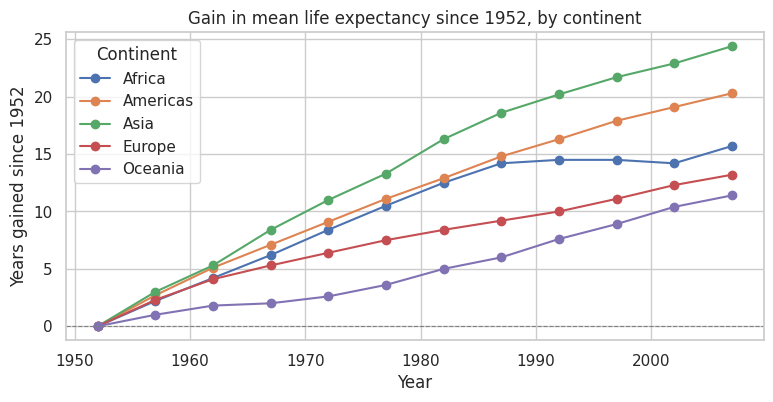

In [6]:
# Step 2: pandas does the analysis and visualization
# Compute how much each continent's life expectancy has grown since 1952
base_1952 = summary.query("year == 1952").set_index("continent")["avg_life"]
summary["gain_since_1952"] = summary["avg_life"] - summary["continent"].map(base_1952)

fig, ax = plt.subplots(figsize=(9, 4))
for continent, group in summary.groupby("continent"):
    ax.plot(group["year"], group["gain_since_1952"], marker="o", label=continent)

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Gain in mean life expectancy since 1952, by continent")
ax.set_xlabel("Year")
ax.set_ylabel("Years gained since 1952")
ax.legend(title="Continent")

Asia shows the steepest trajectory, with a gain of nearly 25 years between 1952 and 2007. Africa's gain stalls in the 1990s, reflecting the AIDS crisis, and then resumes. Europe started from the highest baseline so its gain in absolute terms is the smallest, though its life expectancy was already high in 1952.

This chart could not be produced by SQL alone; the calculation of gain since 1952 required pandas alignment. But it also could not be produced efficiently with pandas alone on a large database; the continent-year aggregation is exactly what SQL is built for. The two tools together produce a result that neither would reach as cleanly on its own.

## SQL is portable across databases

Everything you have written in this module uses SQLite, but the SQL syntax transfers almost unchanged to PostgreSQL, MySQL, Microsoft SQL Server, Google BigQuery, and every other major database system. The aggregate functions, WHERE, GROUP BY, HAVING, and JOIN work the same way everywhere. Minor differences exist; each system has its own date functions and some use `TOP` instead of `LIMIT`, but the core vocabulary is standard.

The `pd.read_sql()` function works with any database connection, not just SQLite. To query a PostgreSQL database at work, you would replace the `sqlite3.connect()` line with a connection from the `psycopg2` or `sqlalchemy` library; everything else stays the same.

This is one of the strongest arguments for learning SQL: it is an investment that pays off on any data system you encounter, not just in Python notebooks.

## Complete SQL–pandas translation table

| Goal | pandas | SQL |
|---|---|---|
| Select columns | `df[["a", "b"]]` | `SELECT a, b FROM table` |
| All columns | `df` | `SELECT * FROM table` |
| Rename column | `df.rename(columns={"old": "new"})` | `SELECT old AS new FROM table` |
| First N rows | `df.head(N)` | `LIMIT N` |
| Unique values | `df["col"].unique()` | `SELECT DISTINCT col FROM table` |
| Sort ascending | `df.sort_values("col")` | `ORDER BY col ASC` |
| Sort descending | `df.sort_values("col", ascending=False)` | `ORDER BY col DESC` |
| Filter rows | `df.query("col > x")` | `WHERE col > x` |
| Match equality | `df.query("col == 'val'")` | `WHERE col = 'val'` |
| Match list | `df["col"].isin([...])` | `WHERE col IN (...)` |
| Exclude list | `~df["col"].isin([...])` | `WHERE col NOT IN (...)` |
| Range filter | `df.query("lo <= col <= hi")` | `WHERE col BETWEEN lo AND hi` |
| String starts with | `df["col"].str.startswith("A")` | `WHERE col LIKE 'A%'` |
| Count rows per group | `groupby(col).size()` | `COUNT(*) ... GROUP BY col` |
| Count non-null | `groupby(col)["c"].count()` | `COUNT(c) ... GROUP BY col` |
| Count distinct | `.nunique()` | `COUNT(DISTINCT col)` |
| Mean per group | `groupby(col)["v"].mean()` | `AVG(v) ... GROUP BY col` |
| Sum per group | `groupby(col)["v"].sum()` | `SUM(v) ... GROUP BY col` |
| Min / Max per group | `.min()` / `.max()` | `MIN(v)` / `MAX(v)` |
| Multiple aggregations | `.agg(["mean", "min"])` | `AVG(v), MIN(v)` in SELECT |
| Filter groups | `groupby(col).filter(lambda g: ...)` | `HAVING condition` |
| Combine tables (inner) | `df1.merge(df2, on="key")` | `INNER JOIN t2 ON t1.key = t2.key` |
| Combine tables (left) | `df1.merge(df2, on="key", how="left")` | `LEFT JOIN t2 ON t1.key = t2.key` |
| Compare to computed value | `df.query("col > @var")` | `WHERE col > (SELECT AVG(col) FROM ...)` |

## What's next

Notebook 10.7 is a set of exercises covering the full module: `df.query()`, SQLite setup, SELECT and WHERE, GROUP BY and HAVING, JOIN, and subqueries. The exercises progress from straightforward recall to questions that combine multiple clauses and require you to choose between a SQL and a pandas approach.